# 📝 LinkedIn Post Generator Agent

A **LangGraph** agent with two nodes:

| Node | Model | Role |
|------|-------|------|
| **Generator** | `gemini-3.5-flash-lite` | Searches the web (Tavily) for fresh info, then drafts a ≤ 250-word LinkedIn post |
| **Reviewer** | `gemini-3.1-flash-lite` | Reviews the draft — either **accepts** or sends **feedback** back (max 3 rounds) |

```
          ┌──────────────────────────────────────┐
          │           START                      │
          └──────────────┬───────────────────────┘
                         ▼
               ┌─────────────────┐
          ┌───▶│    Generator    │◀── (tool call) ──▶ Tavily Search
          │    └────────┬────────┘
          │             ▼
          │    ┌─────────────────┐
          │    │    Reviewer     │
          │    └────────┬────────┘
          │             │
          │      accepted? ──yes──▶ END
          │             │
          │            no (+ feedback)
          │             │
          └─────────────┘  (max 3 attempts)
```

In [28]:
from typing import Annotated, TypedDict
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
# ---------------------------------------------------------------------------
# 1. TOOLS — Tavily web search for fetching latest info on a topic
# ---------------------------------------------------------------------------

tavily_search = TavilySearch(
    max_results=4,
    topic="general",
)

tools = [tavily_search]

In [30]:
# ---------------------------------------------------------------------------
# 2. STATE — carries everything between nodes.
#    - messages      : full conversation history (generator sees all feedback)
#    - draft         : the latest LinkedIn post draft
#    - review        : the reviewer's latest verdict / feedback
#    - attempt_count : how many drafts the generator has produced (max 3)
#    - accepted      : True once the reviewer approves the draft
# ---------------------------------------------------------------------------

class State(TypedDict):
    messages: Annotated[list, add_messages]   # full message history for context
    draft: str                                 # latest LinkedIn post draft
    review: str                                # reviewer's feedback
    attempt_count: int                         # current attempt number
    accepted: bool                             # whether the draft is accepted

In [31]:
# ---------------------------------------------------------------------------
# 3. LLMs — two separate models for generator and reviewer
# ---------------------------------------------------------------------------

generator_llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
generator_llm_with_tools = generator_llm.bind_tools(tools)  # can call Tavily

reviewer_llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

In [32]:
# ---------------------------------------------------------------------------
# 4. SYSTEM PROMPTS
# ---------------------------------------------------------------------------

GENERATOR_SYSTEM_PROMPT = """You are an expert LinkedIn content creator.

Your job:
1. Use the Tavily search tool to find the latest, most relevant information on the given topic.
2. Using the search results, write a professional LinkedIn post draft.

Draft rules:
- Maximum 250 words (strictly enforced).
- Start with a bold, attention-grabbing hook (first 1-2 lines are critical).
- Use short paragraphs, line breaks, and relevant emojis for readability.
- Include 2-3 actionable insights or key takeaways.
- End with a thought-provoking question or clear call-to-action.
- Add 3-5 relevant hashtags at the bottom.
- Tone: professional yet conversational — no corporate jargon.

If you receive reviewer feedback, carefully address every point in your revision.

Return ONLY the post text. No extra commentary."""


REVIEWER_SYSTEM_PROMPT = """You are a senior LinkedIn content strategist and editor.

Review the draft LinkedIn post against these criteria:
1. Hook strength — do the first 2 lines grab attention instantly?
2. Word count — is it 250 words or fewer?
3. Value — does it offer genuine insights, not generic fluff?
4. Readability — short paragraphs, line breaks, good formatting?
5. CTA — does it end with engagement-driving question or call-to-action?
6. Hashtags — are there 3-5 relevant hashtags?
7. Tone — professional yet approachable?

Your response MUST follow this exact format:

DECISION: ACCEPT or REVISE
FEEDBACK: <your detailed feedback here — be specific about what to fix>

Be constructive but strict. Only ACCEPT if the post is truly publish-ready."""

In [33]:
# ---------------------------------------------------------------------------
# 5. NODES
# ---------------------------------------------------------------------------

def extract_text(content) -> str:
    """Extract plain text from an LLM response content.

    Gemini can return content as a list of dicts like
    [{'type': 'text', 'text': '...'}] instead of a plain string."""
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = [item["text"] for item in content if isinstance(item, dict) and "text" in item]
        return "\n".join(parts)
    return str(content)


def generator_node(state: State) -> dict:
    """Generate / revise a LinkedIn post. Uses Tavily search for fresh data."""
    attempt = state.get("attempt_count", 0) + 1
    print(f"\n{'='*60}")
    print(f"📝 GENERATOR — Attempt {attempt}/3")
    print(f"{'='*60}")

    # Build the full message list: system prompt + conversation history
    messages = [SystemMessage(content=GENERATOR_SYSTEM_PROMPT)] + list(state["messages"])

    # The generator may call Tavily search — run the ReAct loop
    response = generator_llm_with_tools.invoke(messages)

    # If the LLM wants to call a tool, return immediately so the
    # ToolNode can execute it and we come back to the generator.
    if getattr(response, "tool_calls", None):
        return {
            "messages": [response],
            "attempt_count": attempt,
        }

    # No tool call — the response IS the draft
    draft = extract_text(response.content)
    print(f"\n--- Draft (Attempt {attempt}) ---")
    print(draft)

    return {
        "messages": [response],
        "draft": draft,
        "attempt_count": attempt,
    }


# Pre-built ToolNode handles executing the Tavily search tool
tool_node = ToolNode(tools)


def reviewer_node(state: State) -> dict:
    """Review the current draft and decide: ACCEPT or REVISE."""
    draft = state["draft"]
    attempt = state["attempt_count"]

    print(f"\n{'='*60}")
    print(f"🔍 REVIEWER — Evaluating Attempt {attempt}/3")
    print(f"{'='*60}")

    review_messages = [
        SystemMessage(content=REVIEWER_SYSTEM_PROMPT),
        HumanMessage(content=f"Review this LinkedIn post draft:\n\n{draft}"),
    ]

    response = reviewer_llm.invoke(review_messages)
    review_text = extract_text(response.content)

    print(f"\n--- Review ---")
    print(review_text)

    accepted = "DECISION: ACCEPT" in review_text.upper()

    # If rejected, attach the feedback as a human message so the
    # generator can see the full context and improve.
    new_messages = []
    if not accepted:
        feedback_msg = HumanMessage(
            content=(
                f"The reviewer has rejected your draft (attempt {attempt}/3).\n"
                f"Here is their feedback — please revise accordingly:\n\n{review_text}"
            )
        )
        new_messages.append(feedback_msg)

    return {
        "messages": new_messages,
        "review": review_text,
        "accepted": accepted,
    }

In [34]:
# ---------------------------------------------------------------------------
# 6. EDGES — routing logic
# ---------------------------------------------------------------------------

def after_generator(state: State) -> str:
    """After the generator: if it called a tool, execute the tool.
    Otherwise the draft is ready for review."""
    last_msg = state["messages"][-1]
    if getattr(last_msg, "tool_calls", None):
        return "tools"
    return "reviewer"


def after_reviewer(state: State) -> str:
    """After the reviewer: if accepted OR max attempts reached → END.
    Otherwise loop back to the generator with feedback."""
    if state["accepted"]:
        print("\n✅ Draft ACCEPTED! Ready to publish.")
        return END
    if state["attempt_count"] >= 3:
        print("\n⚠️  Max attempts (3) reached. Using the latest draft.")
        return END
    print("\n🔄 Sending feedback to generator for revision...")
    return "generator"

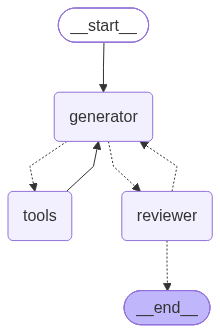

In [35]:
# ---------------------------------------------------------------------------
# 7. GRAPH — wire everything together
#
#   START → generator ──(tool call?)──→ tools → generator
#                    └──(draft ready)──→ reviewer
#                                          │
#                                  accepted / max attempts → END
#                                          │
#                                     (feedback) → generator
# ---------------------------------------------------------------------------

graph = StateGraph(State)

# Add nodes
graph.add_node("generator", generator_node)
graph.add_node("tools", tool_node)
graph.add_node("reviewer", reviewer_node)

# Entry point
graph.set_entry_point("generator")

# Conditional edge after generator: tool call → tools, else → reviewer
graph.add_conditional_edges(
    "generator",
    after_generator,
    {"tools": "tools", "reviewer": "reviewer"},
)

# After tools execute, go back to generator to process the results
graph.add_edge("tools", "generator")

# Conditional edge after reviewer: accept/max → END, else → generator
graph.add_conditional_edges(
    "reviewer",
    after_reviewer,
    {END: END, "generator": "generator"},
)

# Compile
app = graph.compile()
app

In [37]:
# ---------------------------------------------------------------------------
# 8. RUN — give it a topic and watch the generator ↔ reviewer loop
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    topic = "The impact of AI agents on software development in 2026"

    print(f"🚀 Generating LinkedIn post on: '{topic}'\n")

    result = app.invoke({
        "messages": [HumanMessage(content=f"Write a LinkedIn post about: {topic}")],
        "draft": "",
        "review": "",
        "attempt_count": 0,
        "accepted": False,
    })

    # --- Final output ---
    print(f"\n{'='*60}")
    print("📋 FINAL LINKEDIN POST")
    print(f"{'='*60}")
    print(result["draft"])
    print(f"\n--- Attempts used: {result['attempt_count']}/3 ---")
    print(f"--- Accepted: {result['accepted']} ---")

🚀 Generating LinkedIn post on: 'The impact of AI agents on software development in 2026'


📝 GENERATOR — Attempt 1/3

📝 GENERATOR — Attempt 2/3

--- Draft (Attempt 2) ---
**Software development isn’t just about writing code anymore—it’s about orchestration.** 🚀

By 2026, AI agents have transitioned from basic autocomplete tools to autonomous teammates. Instead of spending hours on routine implementation, engineers now act as directors—defining the problems worth solving while multi-agent systems handle the heavy lifting. 

Here are three shifts reshaping engineering this year:

🔹 **From Execution to Validation:** Coding has evolved from manual syntax entry to setting clear objectives and establishing validation protocols. Humans now focus on architecture, logic boundaries, and business impact.

🔹 **Agentic Quality Control:** With massive volumes of AI-generated code, organizations rely on secondary agent layers to autonomously audit for security vulnerabilities, compliance, and archite